In [1]:
!export PYTHON_JULIACALL_THREADS=12

In [22]:
from pyvela import SPNTA, pyvela_plot
from pyvela.sdtsampler import SDTSampler
from pyvela.sampling import get_start_samples
from pint.logging import setup as setup_log

import matplotlib.pyplot as plt
import numpy as np
import corner
import os


In [3]:
spnta = SPNTA(
    "B1855+09_NANOGrav_9yv1.gls.par", 
    "B1855+09_NANOGrav_9yv1.tim", 
    analytic_marginalized_params=["PHOFF", "F", "ELAT", "ELONG", "DM", "FD", "JUMP"], 
    check=False
)

WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
WARNING  (pint.toa                      ): No pulse numbers for TOAs


In [4]:
setup_log(level="ERROR")

3

In [5]:
sdt = SDTSampler(spnta, data_tempering_factor=0.8, ntoa_min=32, nwalkers_per_param=5)

In [6]:
sdt.spnta_subsets

4005


WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.


3202


WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.


2560


...

152


WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.


140


WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.


131
128


In [7]:
x0 = get_start_samples(spnta, 0.3, sdt.nwalkers)

In [8]:
spnta.lnpost_vectorized(x0);

In [9]:
%time sdt.run_mcmc(x0, nsteps_initial=10000, nsteps_mid=1000, nsteps_final=3000)

Iteration 0/20 :: Ntoas = 128


100%|██████████| 10000/10000 [00:24<00:00, 401.35it/s]


Iteration 1/20 :: Ntoas = 131


100%|██████████| 1000/1000 [00:02<00:00, 414.95it/s]


Iteration 2/20 :: Ntoas = 140


...

Iteration 18/20 :: Ntoas = 3202


100%|██████████| 1000/1000 [01:26<00:00, 11.51it/s]


Iteration 19/20 :: Ntoas = 4005


100%|██████████| 3000/3000 [06:31<00:00,  7.65it/s]


CPU times: user 57min 39s, sys: 16.7 s, total: 57min 56s
Wall time: 11min 40s


In [10]:
chains = sdt.get_chains()

In [11]:
nchains = len(chains)

In [12]:
full_chain = np.concatenate(chains, axis=0)

In [13]:
samples_raw = sdt.get_final_chain(flat=True, discard=2000, thin=10)

In [14]:
samples = spnta.rescale_samples(samples_raw)

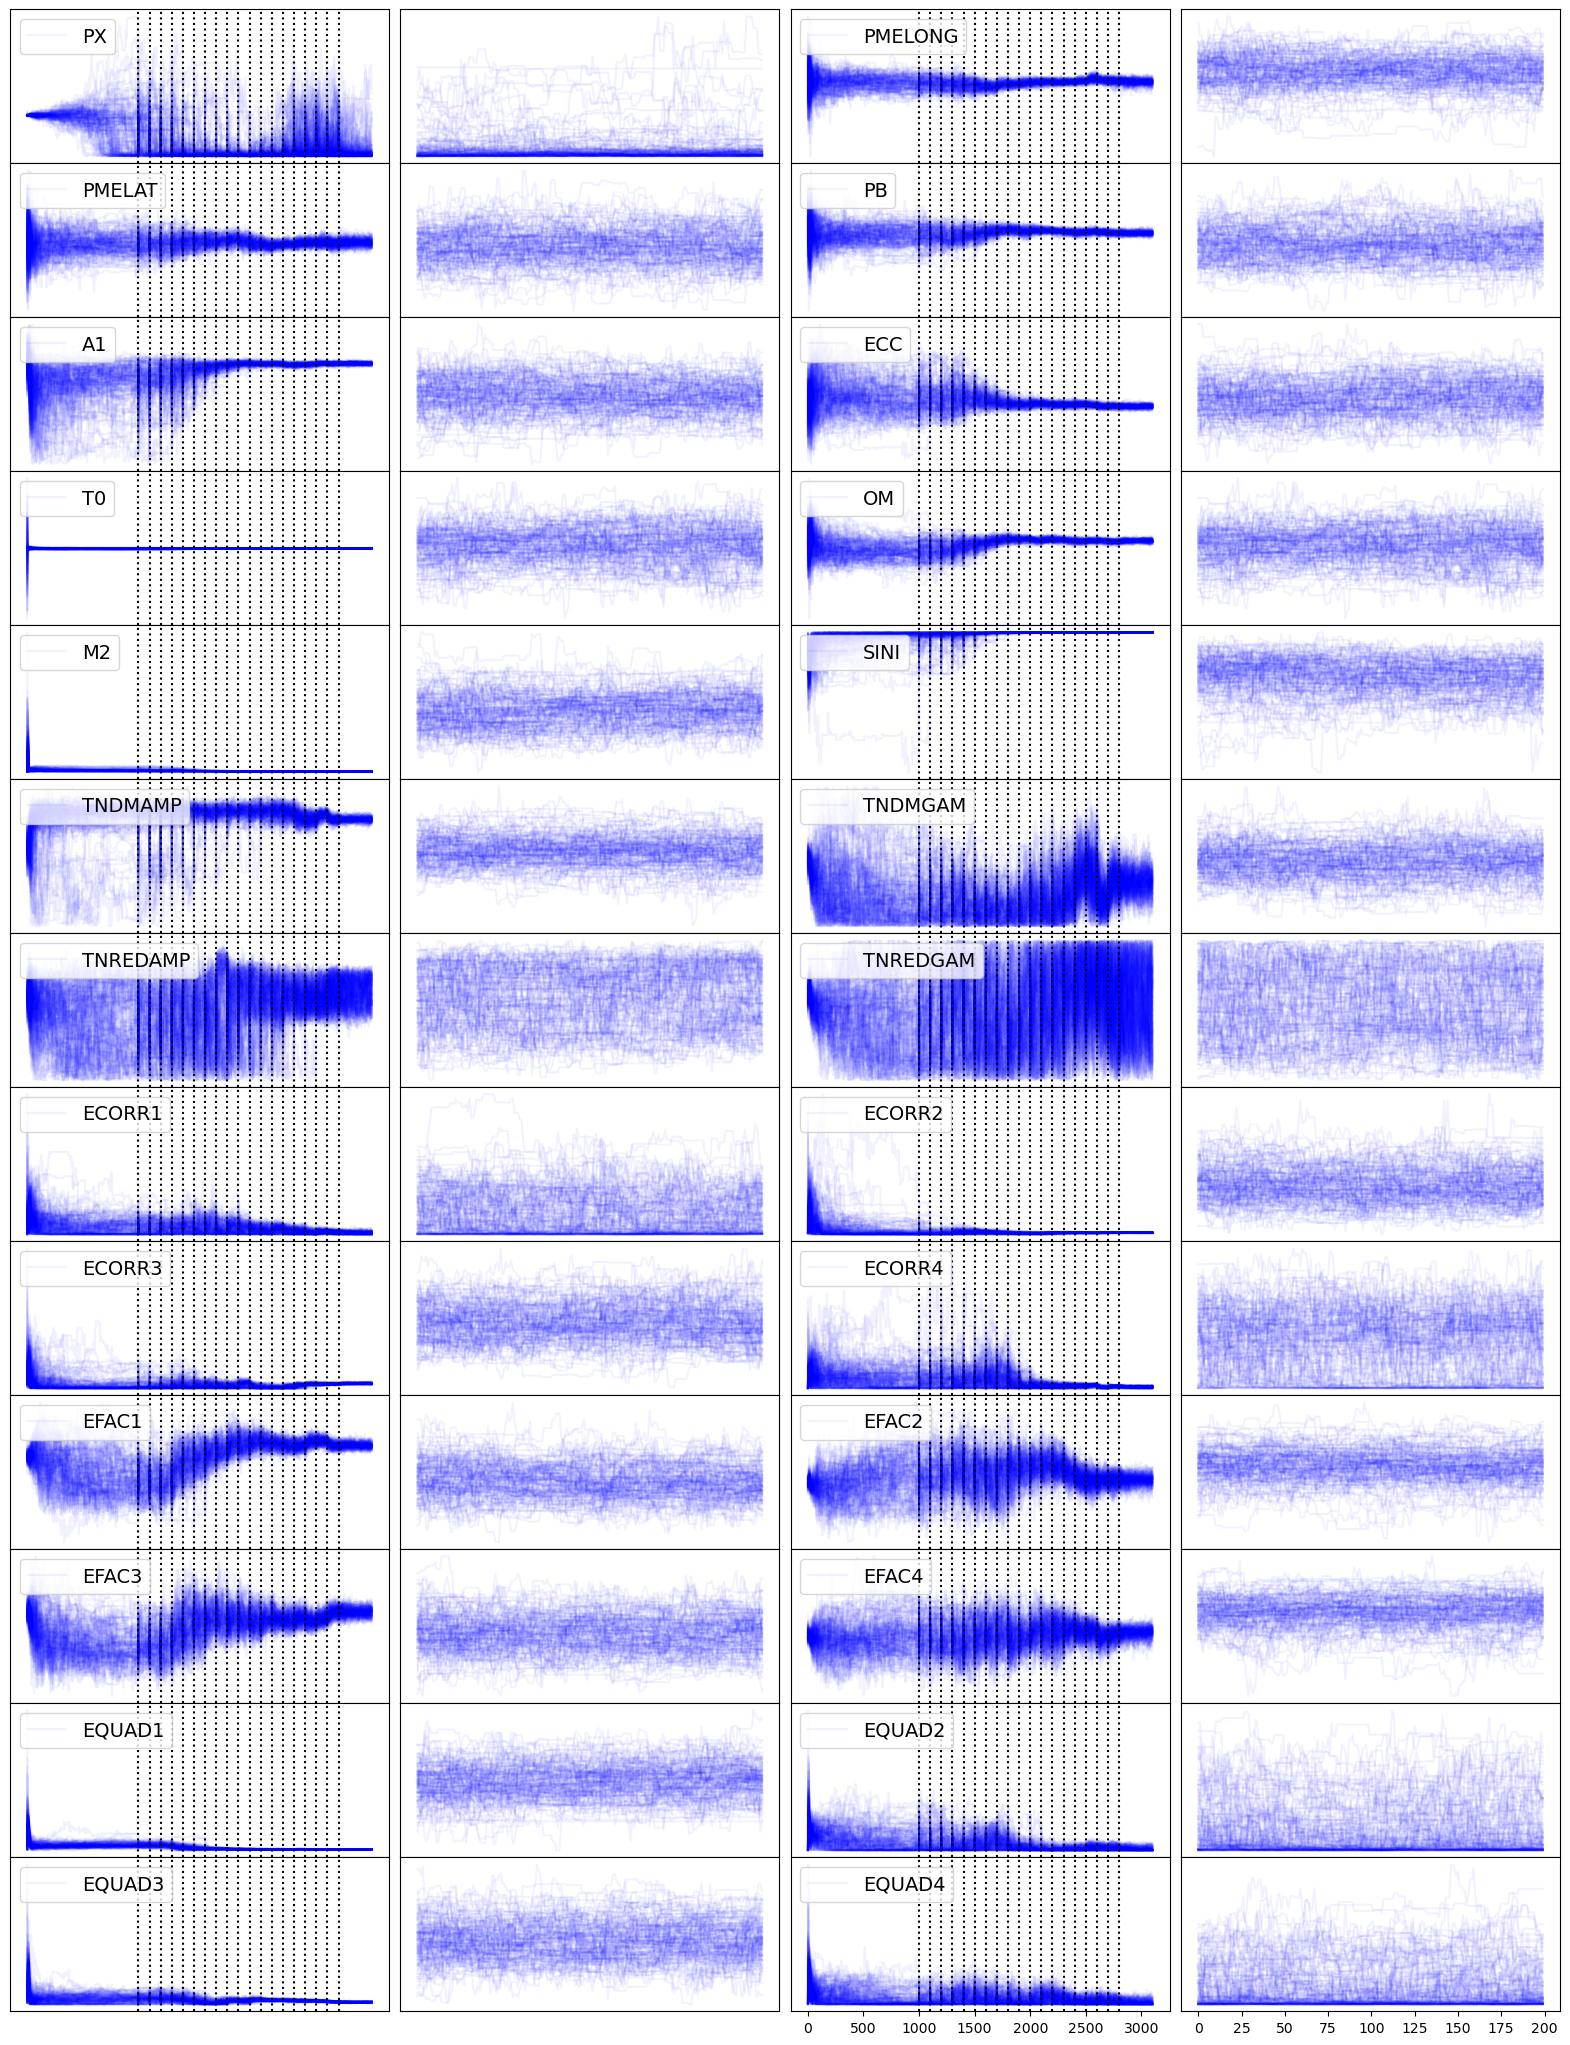

In [15]:
plt.figure(figsize=(20, spnta.ndim))
for ipar, pname in enumerate(spnta.param_names):
    plt.subplot(spnta.ndim//2, 4, 2*ipar+1)
    for w in range(sdt.nwalkers):
        # if w%3==0:
        plt.plot(full_chain[:, w, ipar], color="blue", alpha=0.05, label=(pname if w==0 else None))
    for ww in np.cumsum([chain.shape[0] for chain in chains])[:-1]:
        plt.axvline(ww, color="black", ls="dotted")
    plt.yticks([])
    if ipar < len(spnta.param_names)-1:
        plt.xticks([])
    plt.legend(loc="upper left", fontsize=14)
    # plt.ylabel(pname)

    plt.subplot(spnta.ndim//2, 4, 2*ipar+2)
    for w in range(sdt.nwalkers):
        plt.plot(full_chain[-200:, w, ipar], color="blue", alpha=0.05)
    plt.yticks([])
    if ipar < len(spnta.param_names)-1:
        plt.xticks([])

plt.subplots_adjust(wspace=0.03, hspace=0)
plt.savefig("sdt-out.png")

In [24]:
outdir = "B1855+09_NANOGrav_9yv1_out"

if not os.path.isdir(outdir):
    os.mkdir(outdir)

spnta.save_pre_analysis_summary(outdir, truth_par_file="B1855+09_NANOGrav_9yv1.gls.par")

In [ ]:
spnta.save_results(outdir, samples_raw)

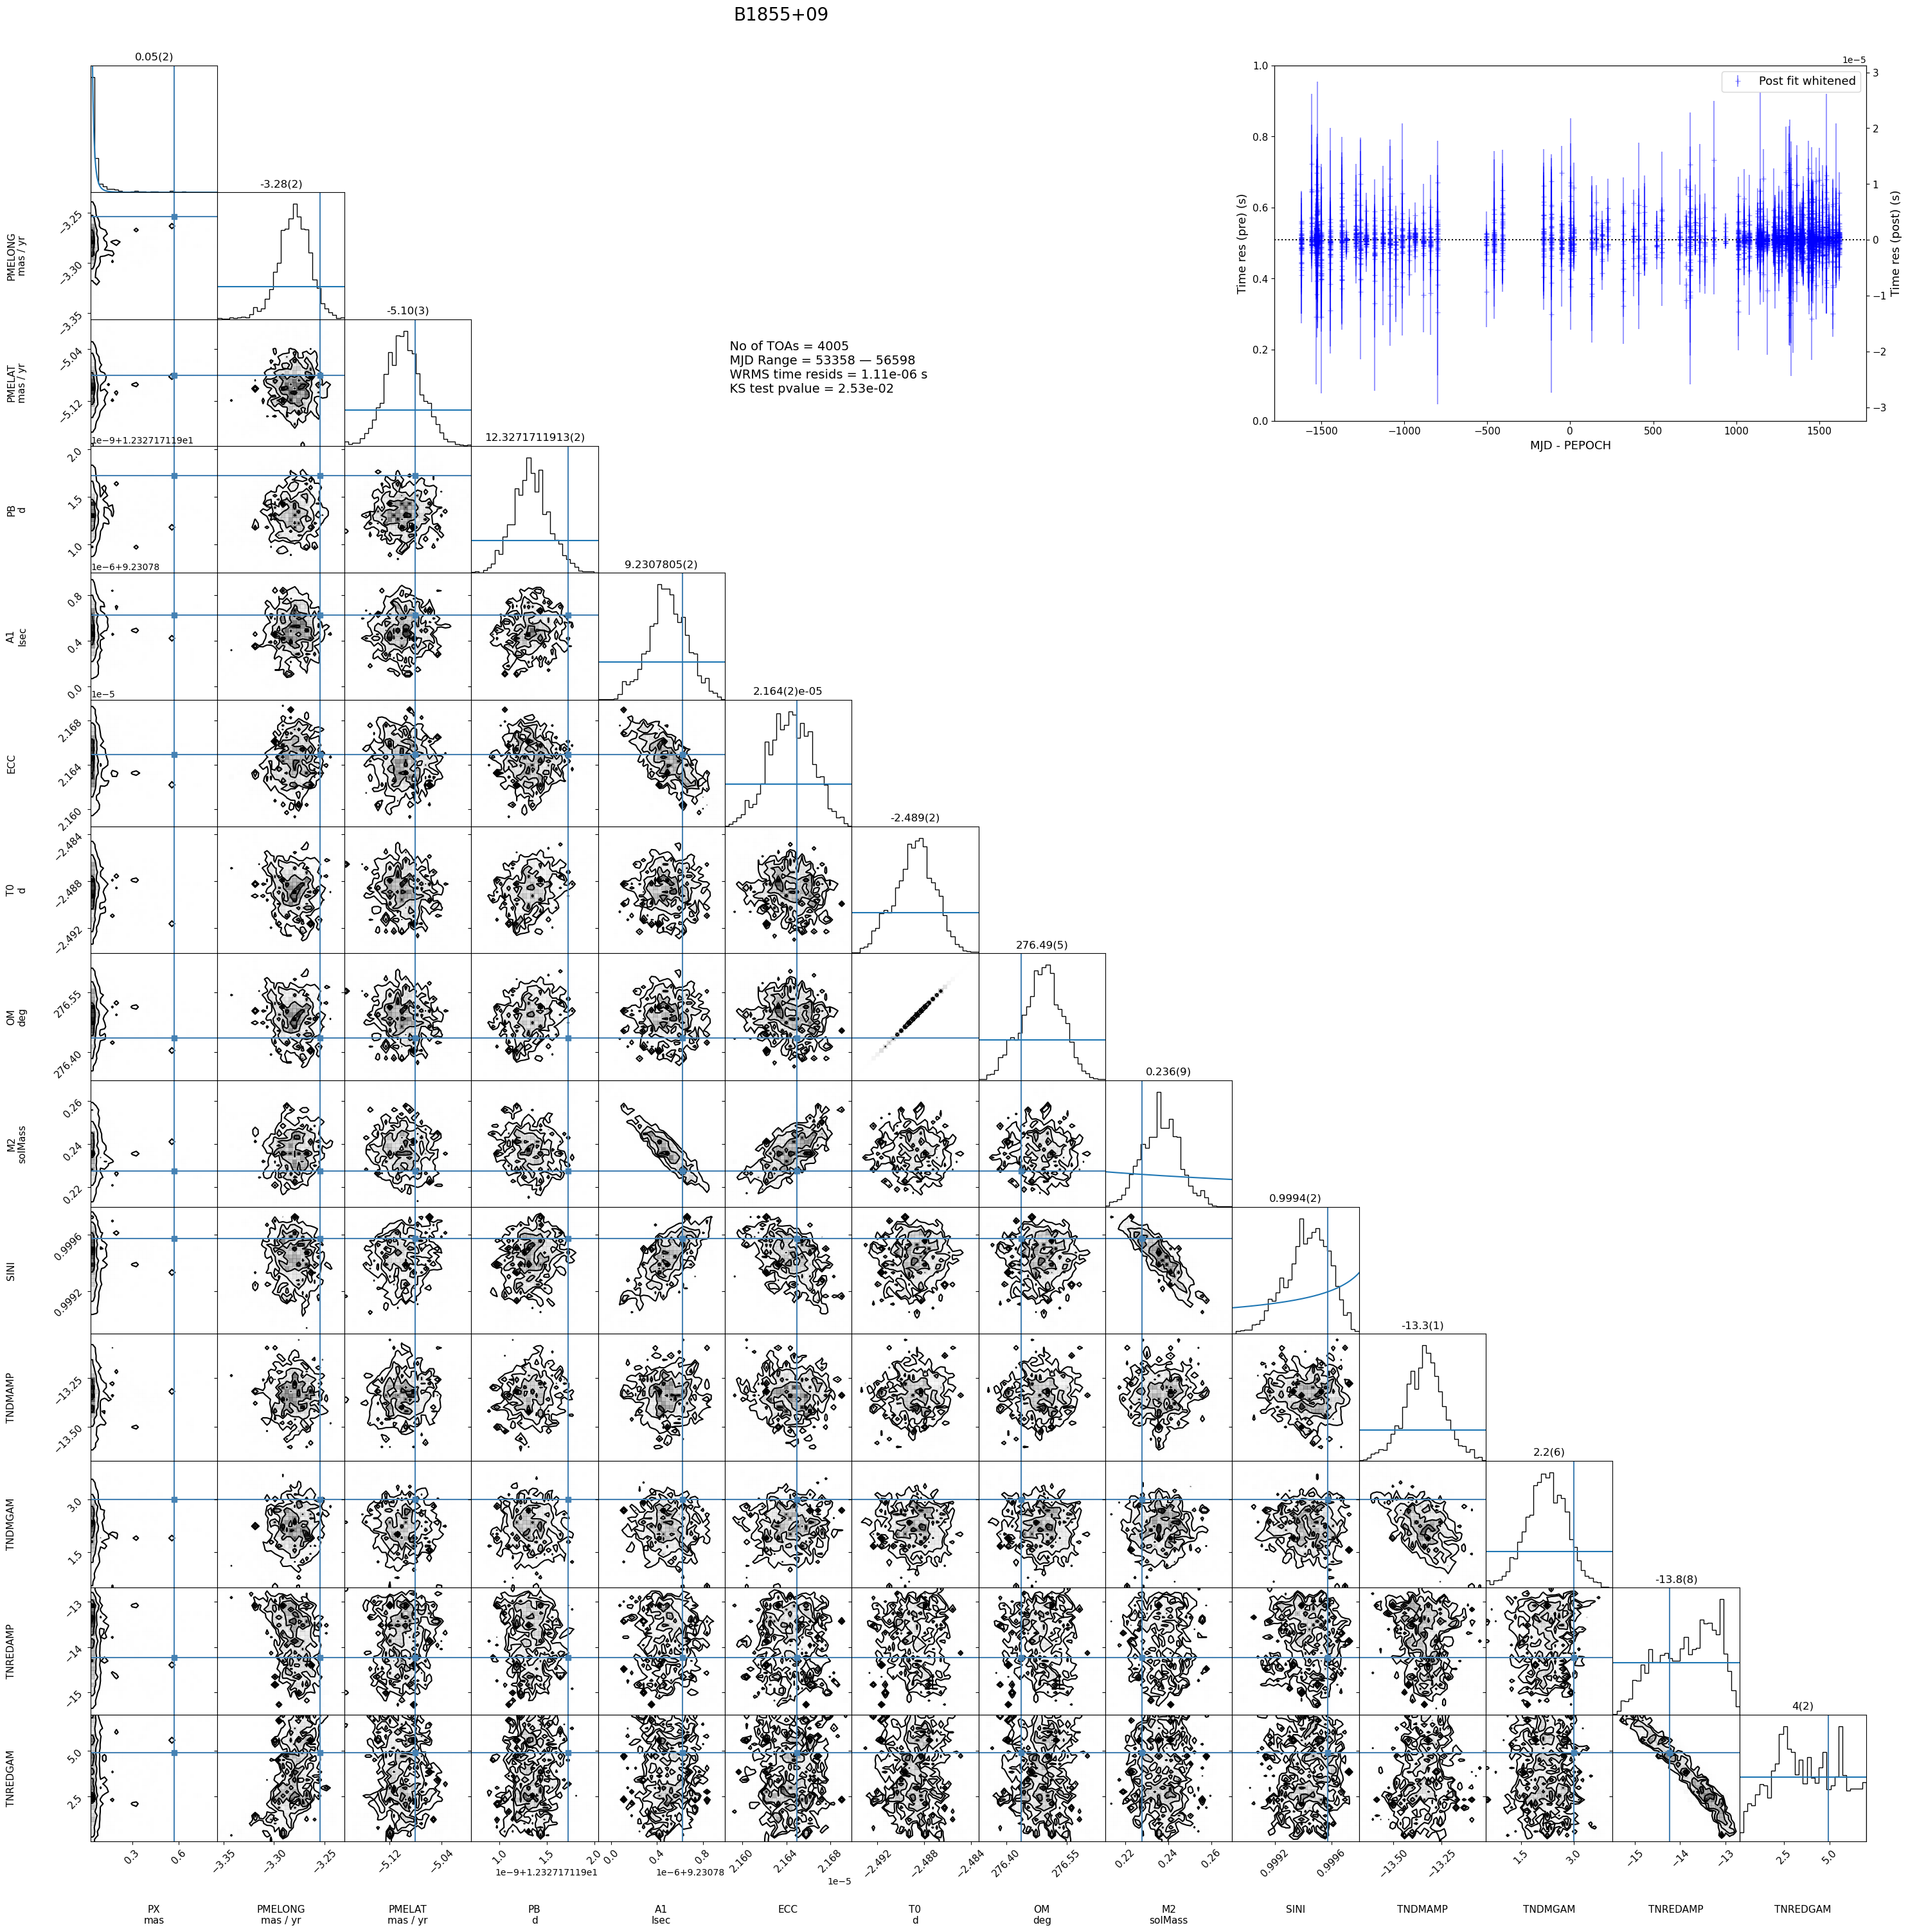

In [25]:
pyvela_plot.plot(
    outdir,
    ignore_params=["EFAC", "EQUAD", "ECORR"],
    plot_priors=True,
)

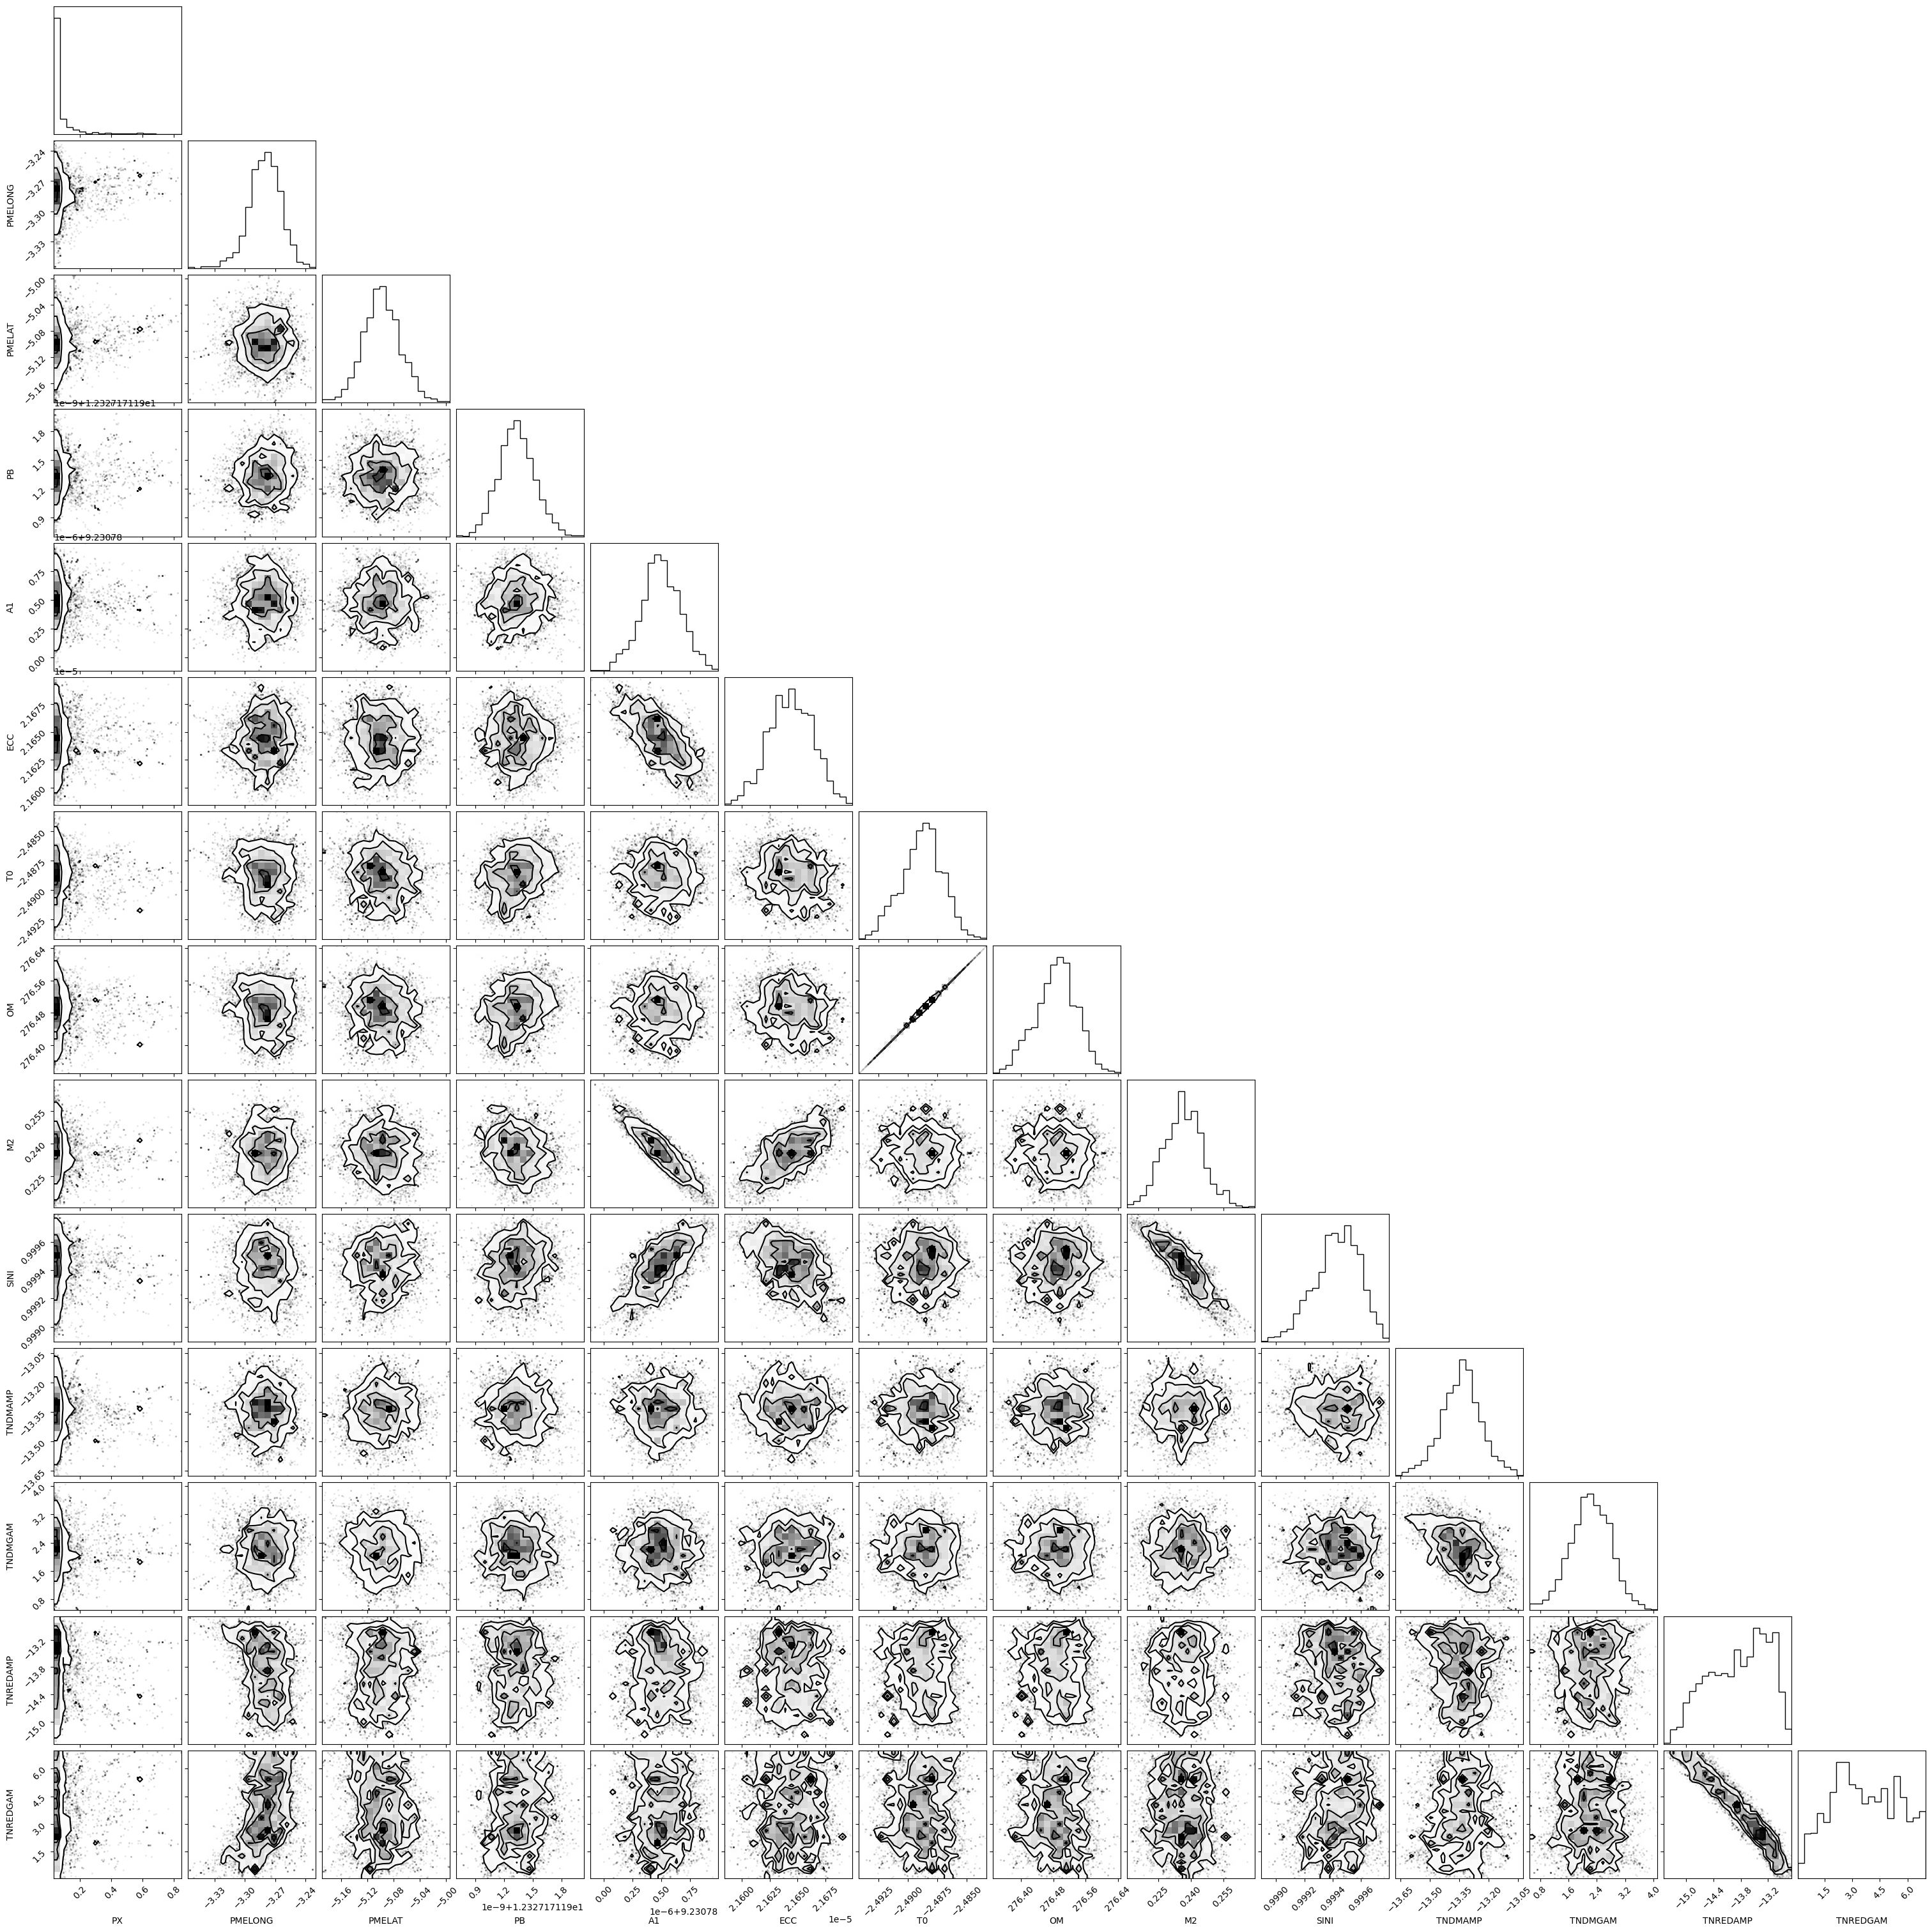

In [ ]:
corner.corner(
    samples[:,:-12], 
    labels=spnta.param_names[:-12], 
    range=[0.999]*len(spnta.param_names[:-12])
);

In [17]:
burnin = 1000
Neff = (sdt.final_sampler.chain.shape[1]-burnin) / np.max(sdt.final_sampler.get_autocorr_time(discard=burnin, tol=10, quiet=True)) * sdt.nwalkers
print(f"Effective number of samples = {Neff}")

Effective number of samples = 1340.3983087220888
